## Model Building Example
M. Schuckers
Created 18 March 2026

This is a file for going through and doing a full model building exercise on some health data by country.

In [28]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from itertools import combinations

import scipy.stats as st
import statsmodels.api as sm 
import pylab as py 

# here are some of the tools we will use for our analyses
from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor


from functools import partial
from sklearn.model_selection import \
     (cross_validate,
      KFold,
      ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm




Source of the data:
[https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)

Note from that site:
The Global Health Observatory (GHO) data repository under World Health Organization (WHO) keeps track of the health status as well as many other related factors for all countries The datasets are made available to public for the purpose of health data analysis. The dataset related to life expectancy, health factors for 193 countries has been collected from the same WHO data repository website and its corresponding economic data was collected from United Nation website. Among all categories of health-related factors only those critical factors were chosen which are more representative. It has been observed that in the past 15 years , there has been a huge development in health sector resulting in improvement of human mortality rates especially in the developing nations in comparison to the past 30 years. Therefore, in this project we have considered data from year 2000-2015 for 193 countries for further analysis. The individual data files have been merged together into a single dataset. On initial visual inspection of the data showed some missing values. As the datasets were from WHO, we found no evident errors. Missing data was handled in R software by using Missmap command. The result indicated that most of the missing data was for population, Hepatitis B and GDP. The missing data were from less known countries like Vanuatu, Tonga, Togo,Cabo Verde etc. Finding all data for these countries was difficult and hence, it was decided that we exclude these countries from the final model dataset. The final merged file(final dataset) consists of 22 Columns and 2938 rows which meant 20 predicting variables. All predicting variables was then divided into several broad categories:​Immunization related factors, Mortality factors, Economical factors and Social factors. 

In [29]:
# read in the monkey data
LifeExp= pd.read_csv("https://webpages.charlotte.edu/mschuck1/classes/DTSC2301/Data/LifeExpectancyData.csv")
# get info about these data
LifeExp.dropna(inplace=True)
# gonna filter to get just the data from 2014 which is most recent
LifeExp=LifeExp[LifeExp['Year'] ==2014]
LifeExp.head(5)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2572,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2573,Albania,2014,Developing,77.5,8.0,0,4.51,428.749067,98.0,0,...,98.0,5.88,98.0,0.1,4575.763787,288914.0,1.2,1.3,0.761,14.2
2574,Algeria,2014,Developing,75.4,11.0,21,0.01,54.237318,95.0,0,...,95.0,7.21,95.0,0.1,547.851700,39113313.0,6.0,5.8,0.741,14.4
2575,Angola,2014,Developing,51.7,348.0,67,8.33,23.965612,64.0,11699,...,68.0,3.31,64.0,2.0,479.312240,2692466.0,8.5,8.3,0.527,11.4
2577,Argentina,2014,Developing,76.2,118.0,8,7.93,847.371746,94.0,1,...,92.0,4.79,94.0,0.1,12245.256450,42981515.0,1.0,0.9,0.825,17.3


In [30]:
#Get the full list of column names
print(LifeExp.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')


We are going to use all of the predictors here except 'Country' and 'Year' or, at least we will consider all of those.

From looking at the head output above, I can see that population has a good deal of variability and as a consequence, I might want consider a log transformation of 'Population'.  Same might be true of GDP.  


### Exploratory Data Analysis (EDA) 

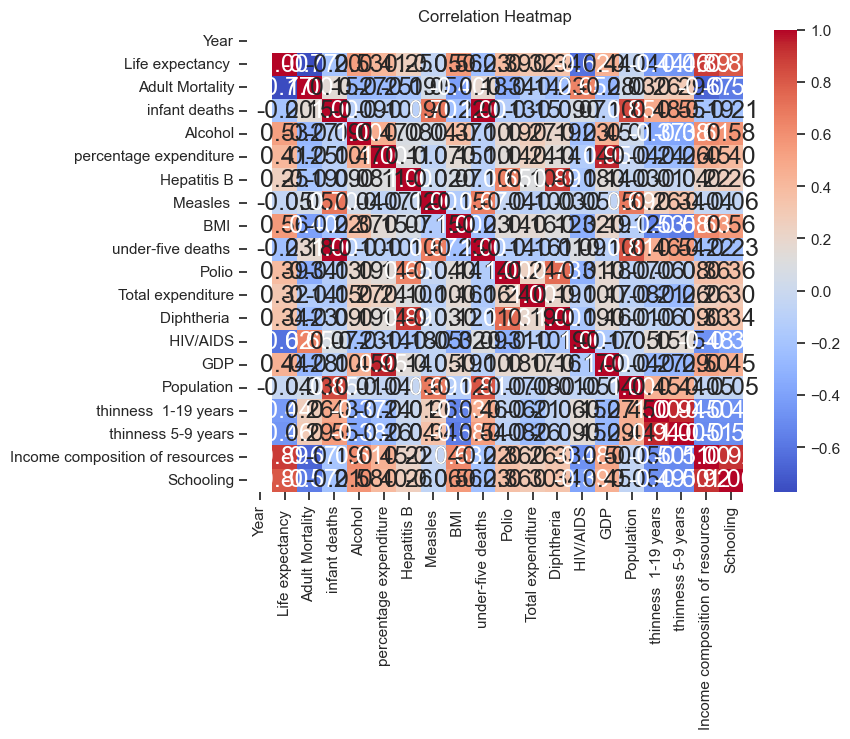

In [31]:
#Basic correlation heatmap
corr = LifeExp.corr(numeric_only=True)

# 3. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

# 4. Display
plt.title("Correlation Heatmap")
plt.show()



There are definitely some concerning elements here.  That is, there are certainly varaibles that have high correlation to each other.

Certainly we don't want both 'under-five deaths' and 'infant deaths'.  Likewise, we don't really need both 'Schooling' and 'Income composition of resources'.  And 'thinness 1-19 years' and 'thinness 5-9 years' are highly correlated.  

Making an decision to remove 'under-five deaths', 'Income Composition of resources' and 'thinness 5-9 years'.  And I'm going to drop 'Year' because we don't need it.

In [32]:
columns_to_remove=['under-five deaths ', 'Income composition of resources',' thinness 5-9 years','Year']
df_le = LifeExp.drop(columns_to_remove, axis=1)

Note that there are some weird spaces in the column names.  Let's get rid of those.

In [33]:
#We are going to do a series of replacements and stripping of white space here and replace any /'s or 
# -'s or with underscores
# also make all of the letter lower case

df_le.columns = df_le.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_')


df_le['log_population']=np.log(df_le['population'])
df_le.columns

Index(['country', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'polio', 'total_expenditure', 'diphtheria',
       'hiv_aids', 'gdp', 'population', 'thinness__1_19_years', 'schooling',
       'log_population'],
      dtype='object')

Next I want to look at the relationships we have for the quantitative features.  

Primarily here I'm looking for possible non-linear relationships.



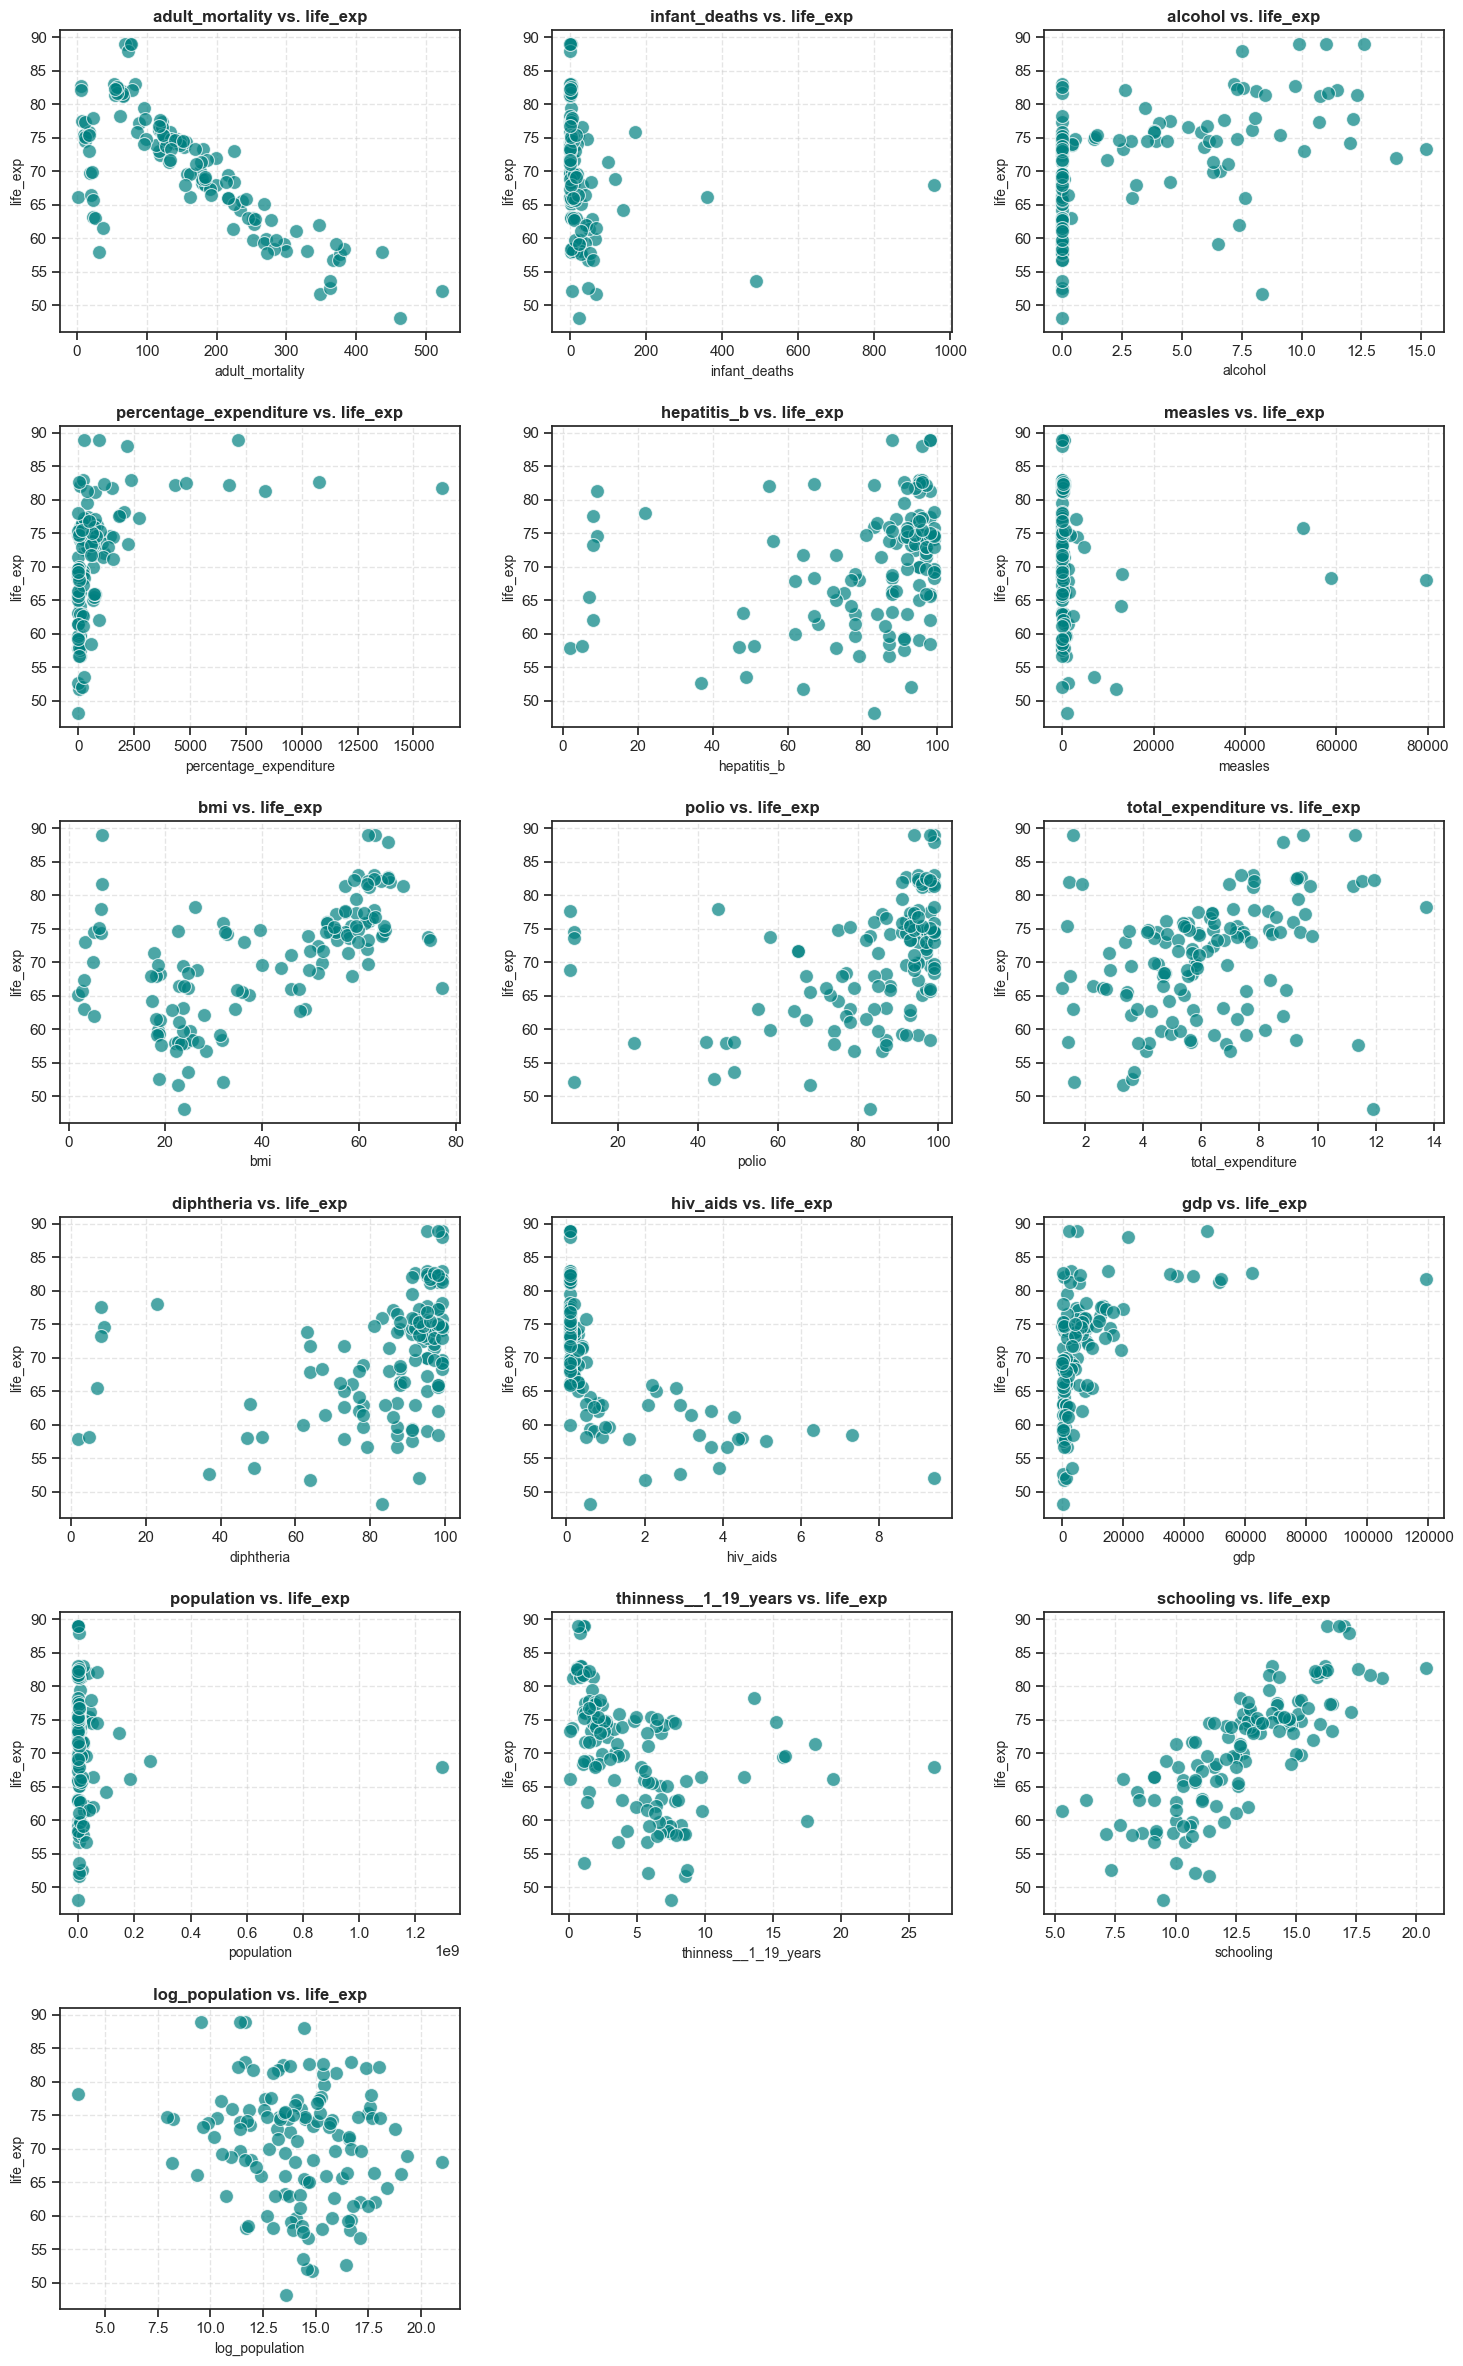

In [34]:
cols_to_plot = df_le.select_dtypes(include=['number']).columns.drop('life_expectancy')

# We define the layout (how many plots per row)
plots_per_row = 3
# Calculate necessary rows based on the number of features
num_rows = (len(cols_to_plot) + plots_per_row - 1) // plots_per_row

# Create the figure and subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, 4 * num_rows))

# Flatten axes array for easy iteration, regardless of layout
axes_flat = axes.flatten()

# Loop through each column and generate its scatterplot
for i, col in enumerate(cols_to_plot):
    # sns.scatterplot handles the plotting on the specified axis (ax=axes_flat[i])
    sns.scatterplot(data=df_le, x=col, y='life_expectancy', ax=axes_flat[i], color='teal', alpha=0.7)
    
    # Customizing each plot
    axes_flat[i].set_title(f'{col} vs. {'life_exp'}', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel(col, fontsize=10)
    axes_flat[i].set_ylabel('life_exp', fontsize=10)
    axes_flat[i].grid(True, linestyle='--', alpha=0.5)

# Hide any empty subplots if the number of features isn't a perfect multiple
for i in range(len(cols_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[i])

# Optimize the layout spacing
plt.tight_layout()

# Display all plots at once
plt.show()

Looking at the output above, I like log_population much better as a predictor even though there seems to not be a relationship there.  Taking the log just makes the values in that feature more spread out.

The other thing that seems to be present is a non-linear relationship with 'bmi'.  I think I can argue that that makes some sense. 

Additionally, there are a handful of variables that seem to be tightly bunched near 0.  

In [35]:
# make a bmi^2 predictor and I'm going to center bmi by its mean
df_le['bmi_z']=df_le['bmi']-np.mean(df_le['bmi'])
df_le['bmi2']=df_le['bmi_z']**2

# note that because there are some countries with 0 measles and 0 infant deaths
# we need to add a value before we take the logs

df_le['log_measles']=np.log(df_le['measles']+1)
df_le['log_infant_deaths']=np.log(df_le['infant_deaths']+1)
df_le['log_gdp']=np.log(df_le['gdp'])
df_le['log_population']=np.log(df_le['population'])
df_le['log_perc_exp']=np.log(df_le['percentage_expenditure'])
df_le['log_hiv_aids']=np.log(df_le['hiv_aids'])
#df_le['log_polio']=np.log(df_le['polio']+1)

df_le = df_le.drop(['infant_deaths','measles','gdp','population','percentage_expenditure','hiv_aids','bmi'], axis=1)

Let's run the plots above again so that we can see how the new scatterplots look

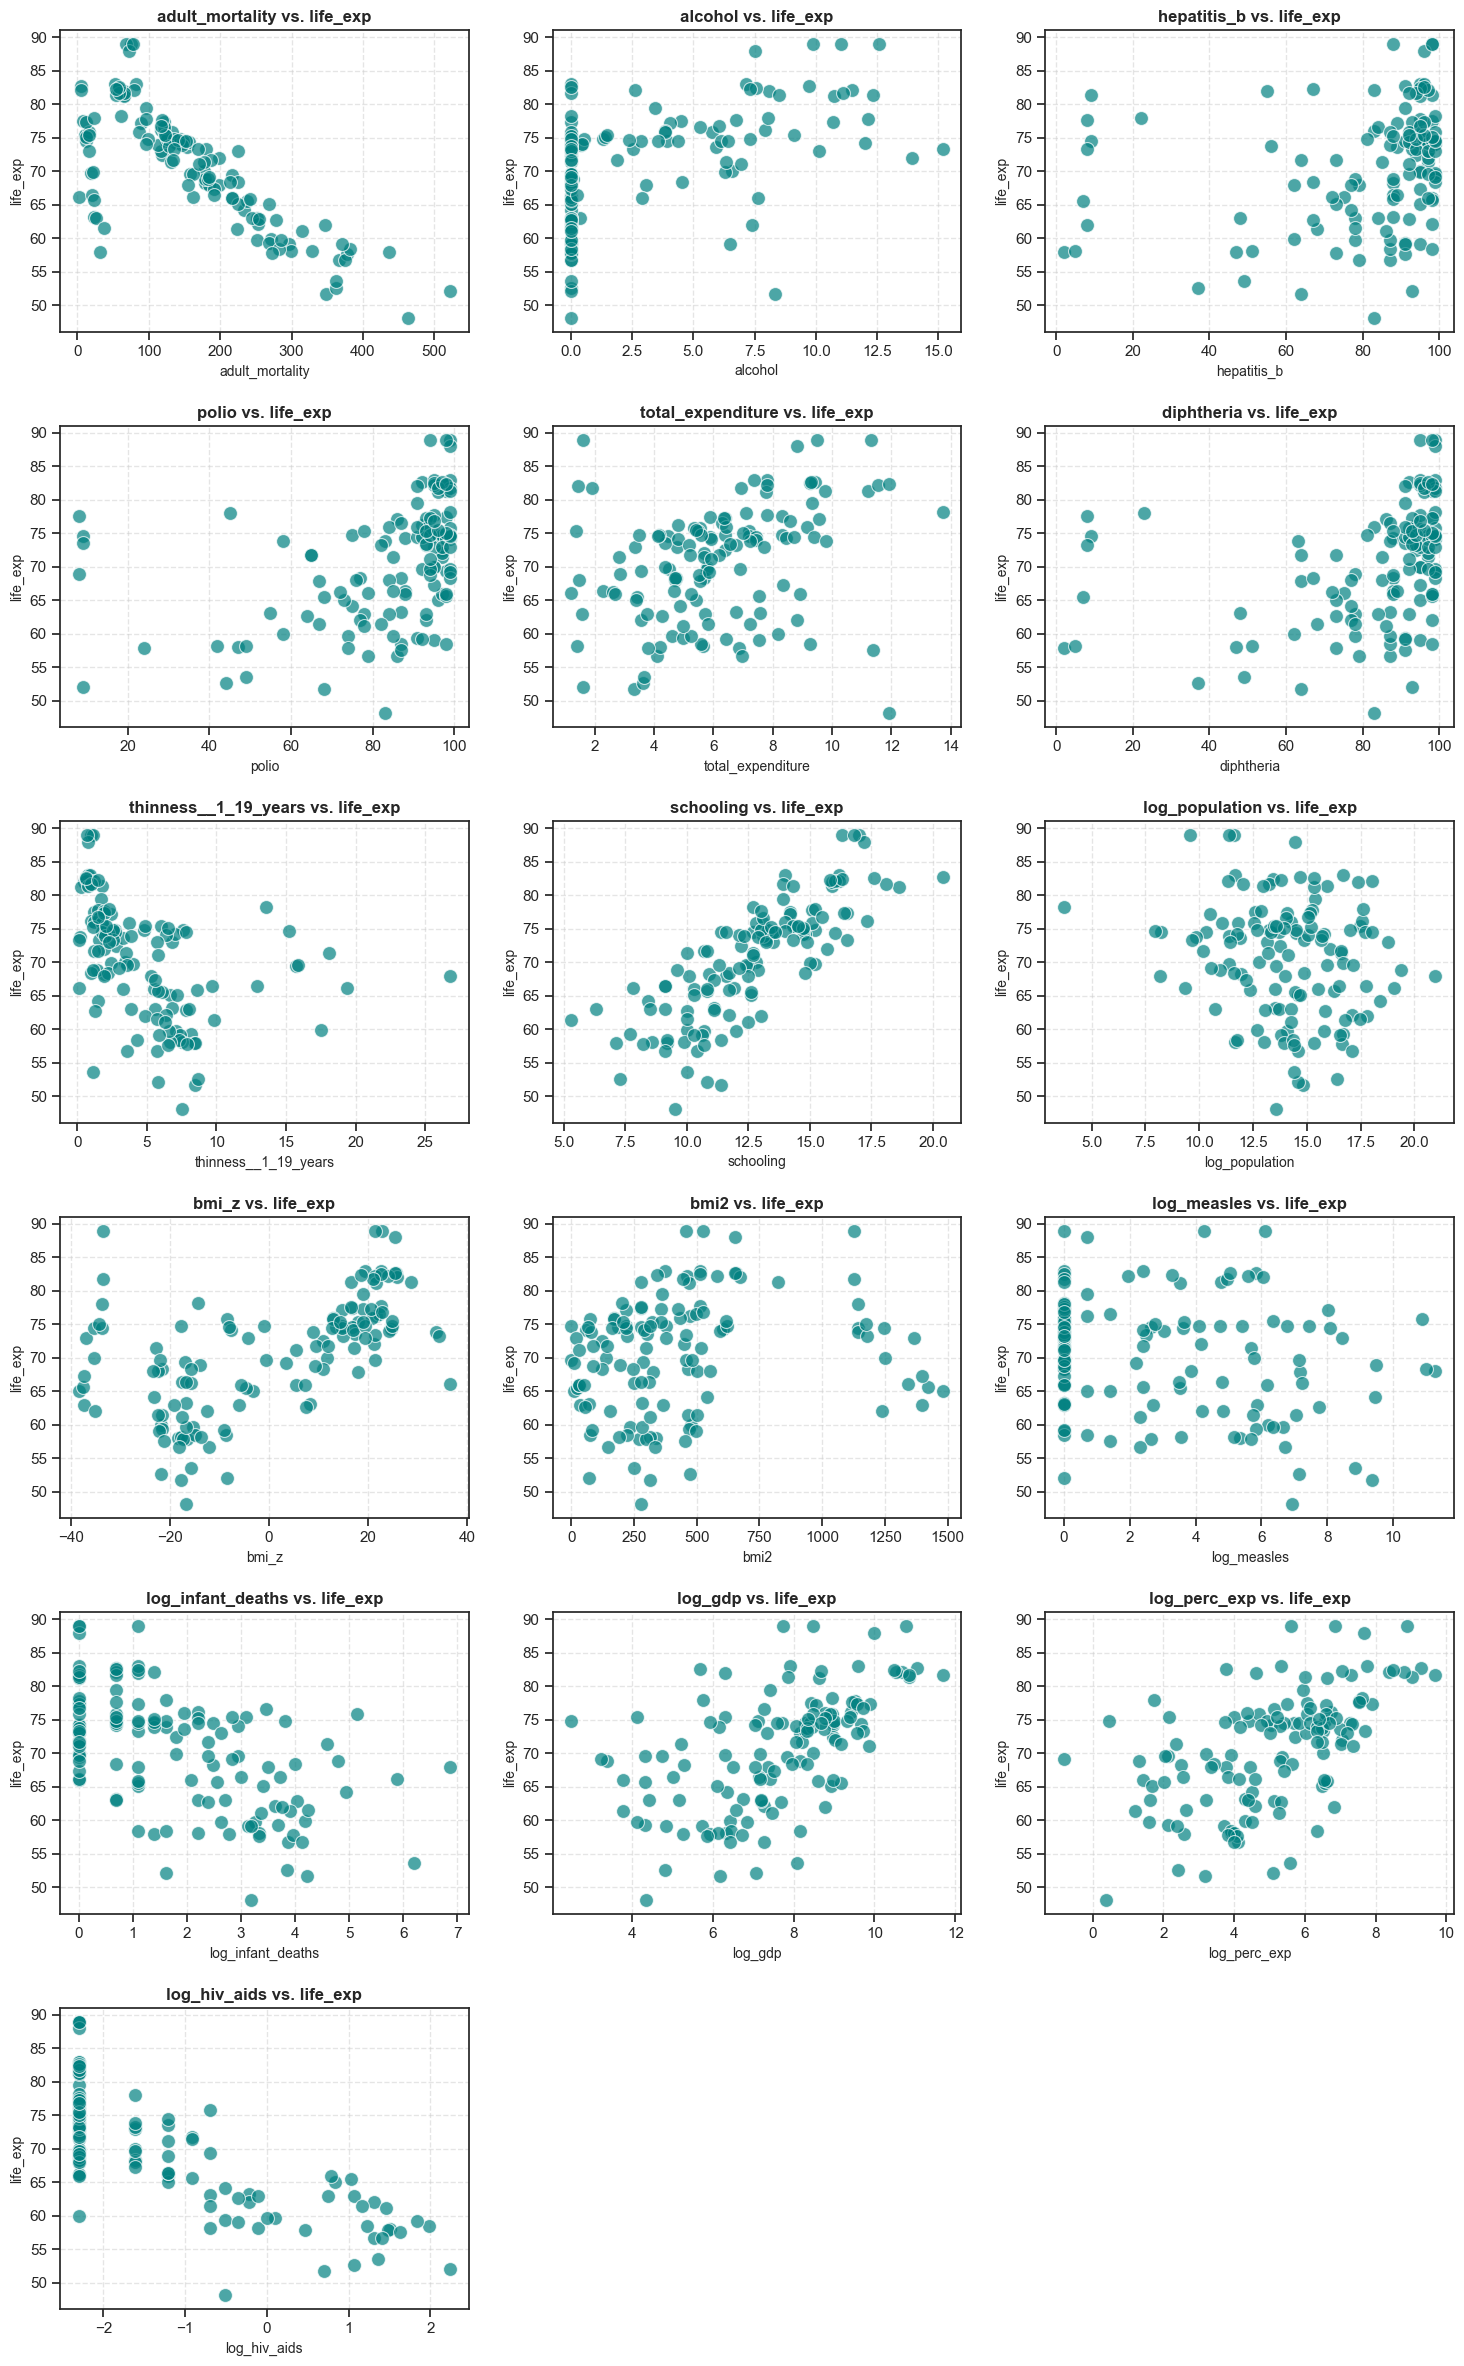

In [36]:
cols_to_plot = df_le.select_dtypes(include=['number']).columns.drop('life_expectancy')

# We define the layout (how many plots per row)
plots_per_row = 3
# Calculate necessary rows based on the number of features
num_rows = (len(cols_to_plot) + plots_per_row - 1) // plots_per_row

# Create the figure and subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, 4 * num_rows))

# Flatten axes array for easy iteration, regardless of layout
axes_flat = axes.flatten()

# Loop through each column and generate its scatterplot
for i, col in enumerate(cols_to_plot):
    # sns.scatterplot handles the plotting on the specified axis (ax=axes_flat[i])
    sns.scatterplot(data=df_le, x=col, y='life_expectancy', ax=axes_flat[i], color='teal', alpha=0.7)
    
    # Customizing each plot
    axes_flat[i].set_title(f'{col} vs. {'life_exp'}', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel(col, fontsize=10)
    axes_flat[i].set_ylabel('life_exp', fontsize=10)
    axes_flat[i].grid(True, linestyle='--', alpha=0.5)

# Hide any empty subplots if the number of features isn't a perfect multiple
for i in range(len(cols_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[i])

# Optimize the layout spacing
plt.tight_layout()

# Display all plots at once
plt.show()

*Note that my above transformations -- all logs -- were not all done at once.  I plotted and iterated several times.

Additional things I considered but did not do: make a log(alcohol) column.  I considered looking at log(polio), log(diptheria), log(hepatitis_b) though there seems to be somewhat of a linear relationship there 

Here's another plot that is useful which gives you all of the scatterplots for all of the features.  Note that if you hover over the figure, you can select the center icon which looks like a histogram to expand the figure so you can see more details.

Note that this plot gets very busy when you have >20 features.

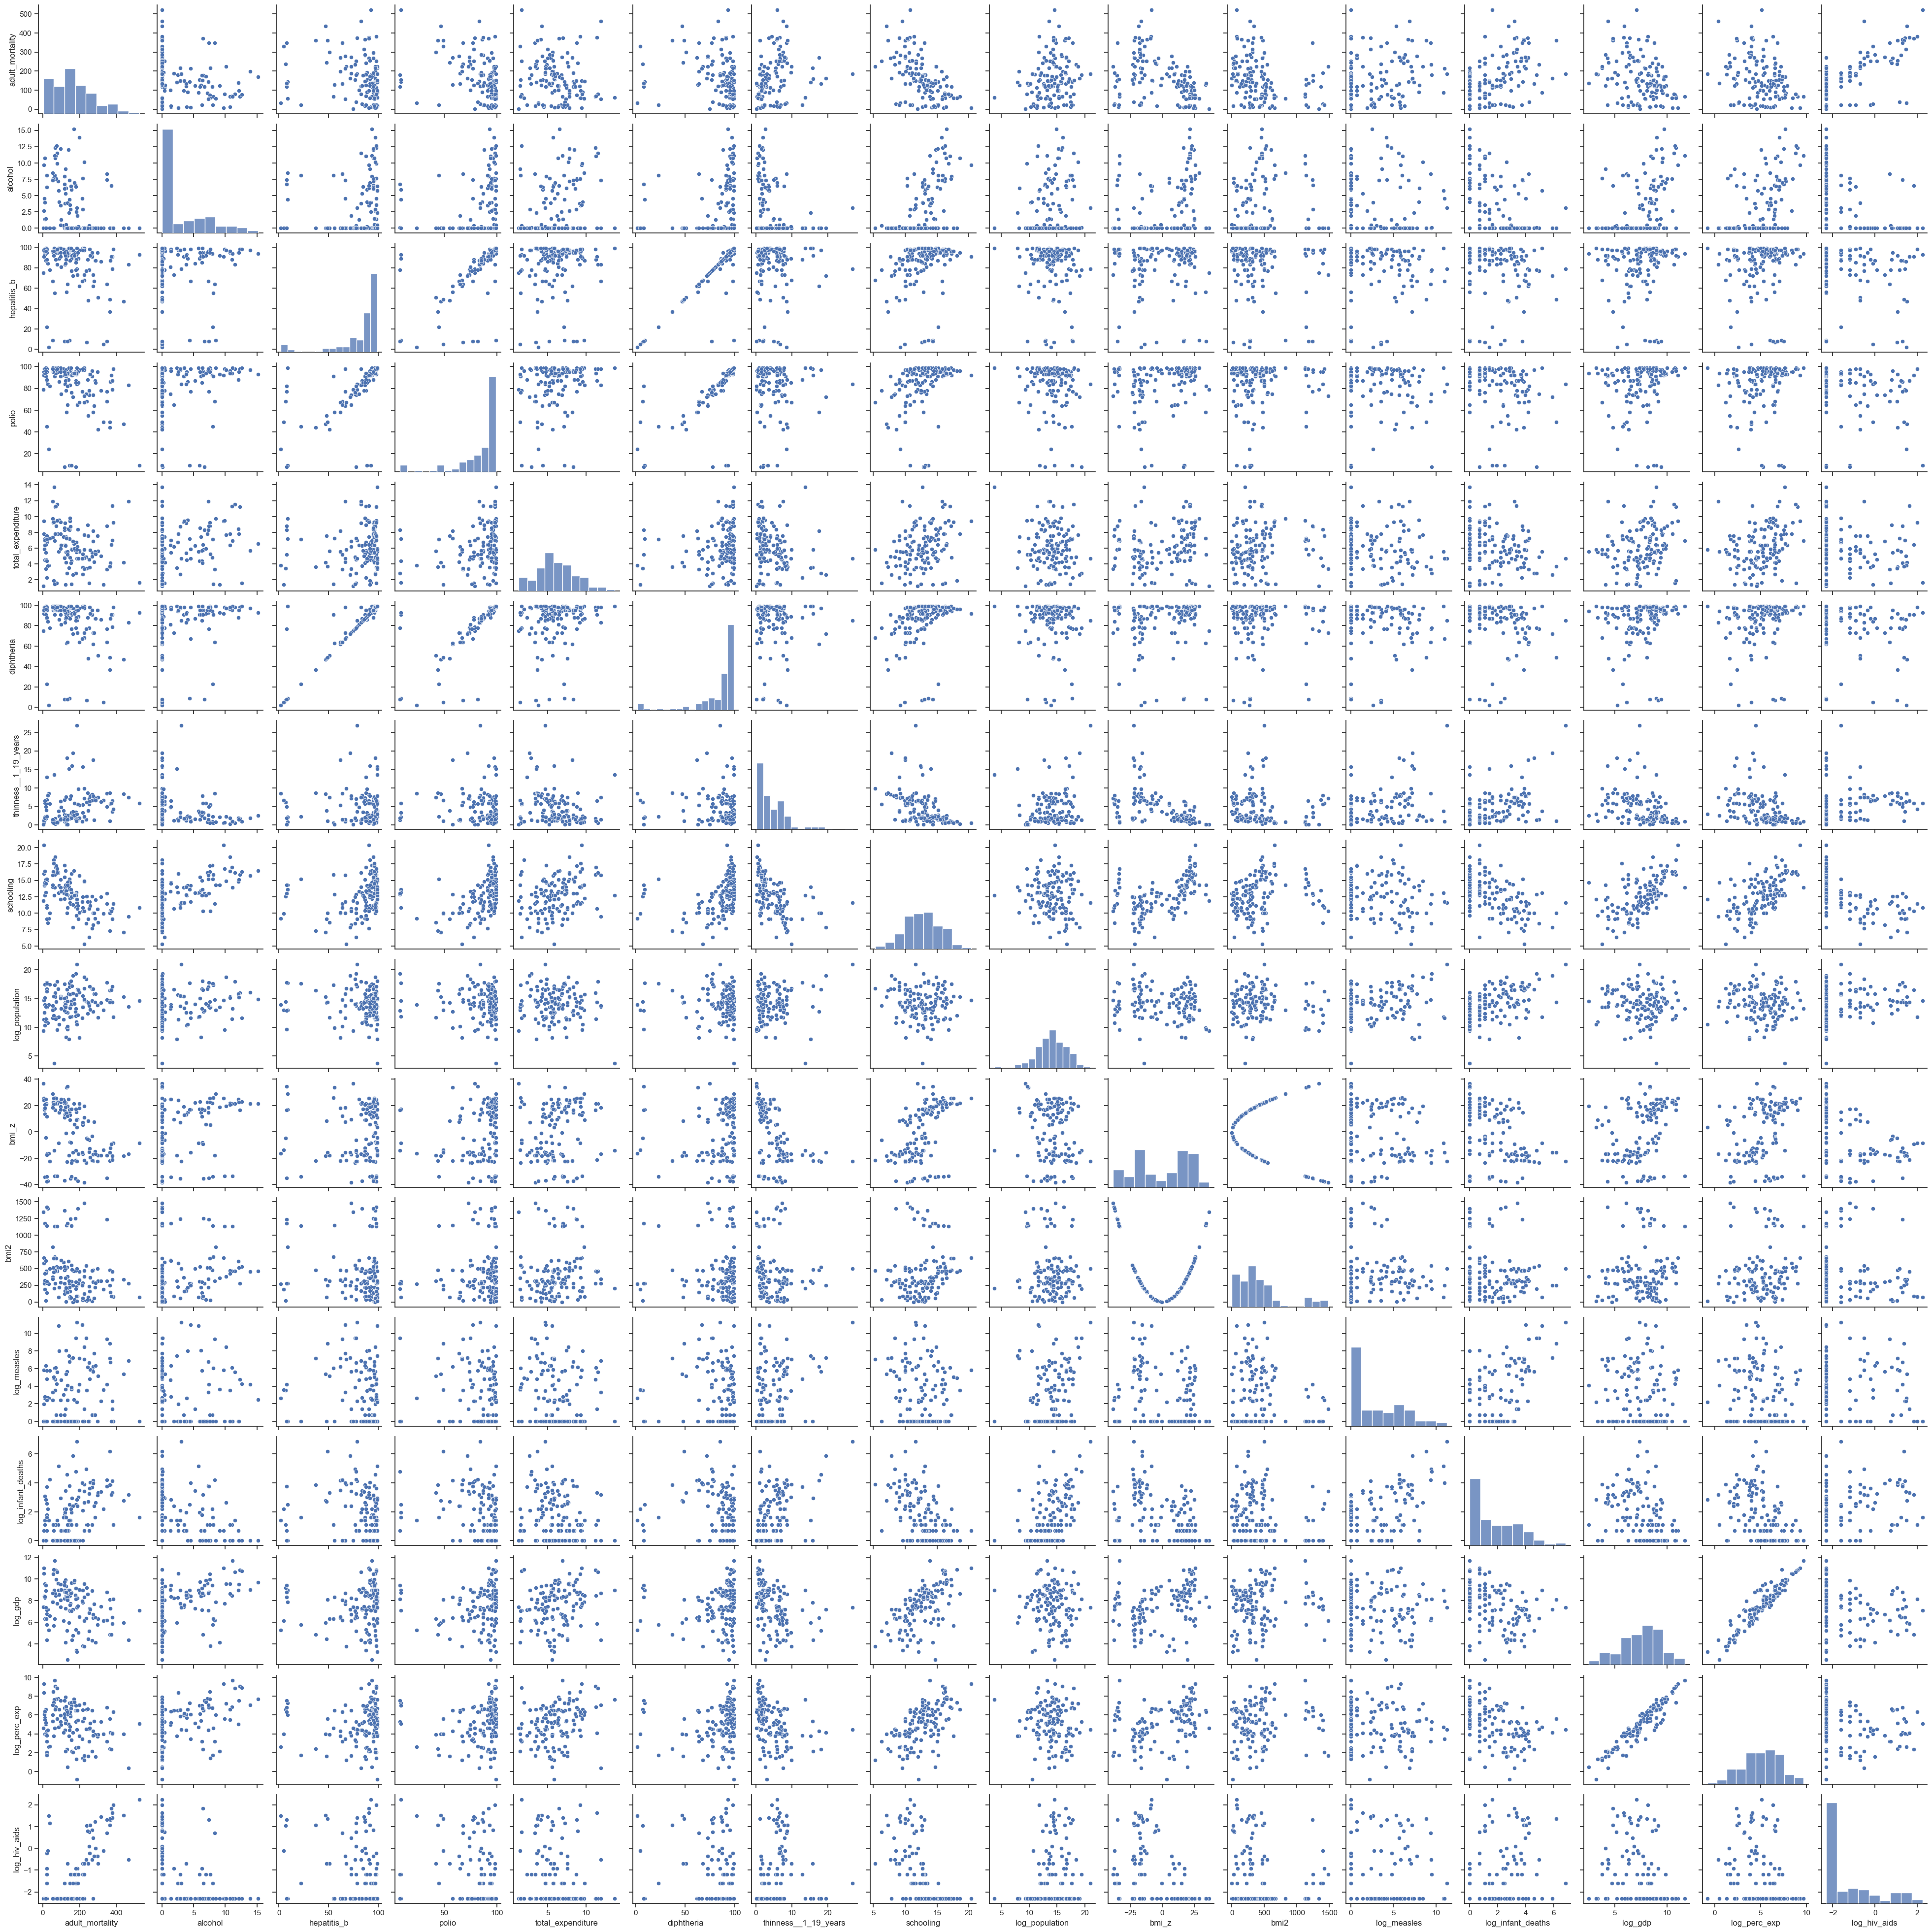

In [37]:
#need to recreate the cols_to_plot
cols_to_plot = df_le.select_dtypes(include=['number']).columns.drop('life_expectancy')
sns.set_theme(style="ticks")

# Simple grid scatterplot of ALL numeric columns
# hue is not specified, so colors are uniform.
sns.pairplot(df_le[cols_to_plot])

# Display the entire grid
plt.show()

Note that on the diagonal of this figure is a histogram of each feature.  This graph is all about detecting multicollinearity.  

From looking at the plot above, I can see a couple of variables that have pretty strong linear relationships that will make me nervous about multicollinearity if I put them both/all in a model.

I see two groups (log_gdp and log_population) and (polio, hepatitis_b and diphtheria).  I think we need to only keep one variable from each group.  I'm going to keep 'log_gdp' and 'log_hepatitis_b'.  It seems to me that the log_gdp has a stronger relationships with life_expectancy from the scatterplots above.  For the second group which I think of as more health related, I'm going to keep 'hepatitis_b' 
without much of a good reason.  Down the line, I think that the effect we assign to 'hepatitis_b' can be thought of more as an overall health measure of the country.  

In [38]:
df_le.head()

,country,status,life_expectancy,adult_mortality,alcohol,hepatitis_b,polio,total_expenditure,diphtheria,thinness__1_19_years,schooling,log_population,bmi_z,bmi2,log_measles,log_infant_deaths,log_gdp,log_perc_exp,log_hiv_aids
2572,Afghanistan,Developing,59.9,271.0,0.01,62.0,58.0,8.18,62.0,17.5,10.0,12.699494,-21.875573,478.540673,6.200509,4.174387,6.417870,4.297606,-2.302585
2573,Albania,Developing,77.5,8.0,4.51,98.0,98.0,5.88,98.0,1.2,14.2,12.573884,16.724427,279.706475,0.000000,0.000000,8.428529,6.060872,-2.302585
2574,Algeria,Developing,75.4,11.0,0.01,95.0,95.0,7.21,95.0,6.0,14.4,17.481973,17.924427,321.285101,0.000000,3.091042,6.306005,3.993369,-2.302585
2575,Angola,Developing,51.7,348.0,8.33,64.0,68.0,3.31,64.0,8.5,11.4,14.805968,-17.775573,315.970978,9.367344,4.219508,6.172352,3.176620,0.693147
2577,Argentina,Developing,76.2,118.0,7.93,94.0,92.0,4.79,94.0,1.0,17.3,17.576281,21.724427,471.950749,0.693147,2.197225,9.412894,6.742139,-2.302585


In [39]:
df_le = df_le.drop(['log_population','diphtheria','polio'], axis=1)
df_le.head()

,country,status,life_expectancy,adult_mortality,alcohol,hepatitis_b,total_expenditure,thinness__1_19_years,schooling,bmi_z,bmi2,log_measles,log_infant_deaths,log_gdp,log_perc_exp,log_hiv_aids
2572,Afghanistan,Developing,59.9,271.0,0.01,62.0,8.18,17.5,10.0,-21.875573,478.540673,6.200509,4.174387,6.417870,4.297606,-2.302585
2573,Albania,Developing,77.5,8.0,4.51,98.0,5.88,1.2,14.2,16.724427,279.706475,0.000000,0.000000,8.428529,6.060872,-2.302585
2574,Algeria,Developing,75.4,11.0,0.01,95.0,7.21,6.0,14.4,17.924427,321.285101,0.000000,3.091042,6.306005,3.993369,-2.302585
2575,Angola,Developing,51.7,348.0,8.33,64.0,3.31,8.5,11.4,-17.775573,315.970978,9.367344,4.219508,6.172352,3.176620,0.693147
2577,Argentina,Developing,76.2,118.0,7.93,94.0,4.79,1.0,17.3,21.724427,471.950749,0.693147,2.197225,9.412894,6.742139,-2.302585


All that we have done so far is about our numeric features/predictors/covariates.  We have one categorical variable and we'll use one-hot encoding to make a dummy/indicator variable for it.



In [40]:
one_hot=pd.get_dummies(df_le['status'],dtype=int)
#printing this to verify there are only two categories
print(one_hot)
df_le['developed']=one_hot['Developed']


      Developed  Developing
2572          0           1
2573          0           1
2574          0           1
2575          0           1
2577          0           1
...         ...         ...
2747          0           1
2748          0           1
2749          0           1
2753          0           1
2754          0           1

[131 rows x 2 columns]


In [41]:
# gonna drap the country and status variables now that we have the indicator for developed countries.
df_le = df_le.drop(['country','status'], axis=1)

On the above, I spent a couple of hours.  That was all to get to the set of features that I want to use for further analysis.  This is very common.  I've not started modelling yet and we've put in a bunch of time on this.  However, I think the modelling is going to go way better with all of this work that I have put in.

### Model selection

So we are going to consider a regression with multiple predictors.
Here's my general approach

First I'm going to create a linear regression with all of the predictors.  Just to look at what that gives me.  Looking at output and residual plots.  That should be indicative if there will be issues with multicollinearity, with conditions.

Second, based on what happens in the previous paragraph, if I have to make a transformation of life expectancy then I would do that and go back to the start with what variables are correlated with the 
transformed(target/response).

Third, I'll want to do a version of all subsets regression.


In [42]:


X = df_le.drop(['life_expectancy'],axis=1)
y = df_le['life_expectancy']


# Create a linear regression model
full_model = LinearRegression()

# Fit the model on the  data
full_model.fit(X, y)

# Make predictions on the  data
y_hat = full_model.predict(X)

# Evaluate the model
rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)

x2 = sm.add_constant(X)

#fit linear regression model
full_model_a = sm.OLS(y, x2).fit()

#view model summary
print(full_model_a.summary())

Root Mean Squared Error: 2.98705189195981
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     59.95
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           2.71e-46
Time:                        15:49:36   Log-Likelihood:                -329.23
No. Observations:                 131   AIC:                             688.5
Df Residuals:                     116   BIC:                             731.6
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

Okay, there are several ways we could go next.   I'm going to start by looking at the VIF's here.  

In [43]:
vif_data = pd.DataFrame()
vif_data["feature"] = x2.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(x2.values, i)
                          for i in range(len(x2.columns))]

print(vif_data[1:len(x2.columns)])

                 feature        VIF
1        adult_mortality   2.448785
2                alcohol   1.755890
3            hepatitis_b   1.224017
4      total_expenditure   1.207256
5   thinness__1_19_years   1.813933
6              schooling   3.536740
7                  bmi_z   2.698234
8                   bmi2   1.638155
9            log_measles   1.768231
10     log_infant_deaths   2.652608
11               log_gdp  10.409605
12          log_perc_exp  10.623789
13          log_hiv_aids   2.613053
14             developed   1.616844


Mostly this looks good.  But...  Probably need to drop either log_gdp or log_perc_exp.  I'll go with dropping log_perc_exp.  My primary view for this choice is of life expectancy as an economic effect.  There's probably not a perfect choice here. 



In [44]:
df_le = df_le.drop(['log_perc_exp'], axis=1)

In [45]:


X = df_le.drop(['life_expectancy'],axis=1)

x2 = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = x2.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(x2.values, i)
                          for i in range(len(x2.columns))]

print(vif_data[1:len(x2.columns)])

                 feature       VIF
1        adult_mortality  2.395127
2                alcohol  1.754773
3            hepatitis_b  1.221136
4      total_expenditure  1.162846
5   thinness__1_19_years  1.782939
6              schooling  3.536054
7                  bmi_z  2.672204
8                   bmi2  1.633517
9            log_measles  1.763396
10     log_infant_deaths  2.468110
11               log_gdp  1.646982
12          log_hiv_aids  2.598459
13             developed  1.616307


Ooh.  I feel better now.  Let's rerun the code and try that full regression again.

In [46]:

X = df_le.drop(['life_expectancy'],axis=1)
y = df_le['life_expectancy']


# Create a linear regression model
full_model = LinearRegression()

# Fit the model on the  data
full_model.fit(X, y)

# Make predictions on the  data
y_hat = full_model.predict(X)

# Evaluate the model
rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)

x2 = sm.add_constant(X)

#fit linear regression model
full_model_a = sm.OLS(y, x2).fit()

#view model summary
print(full_model_a.summary())

Root Mean Squared Error: 3.173070626823245
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     56.69
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           3.50e-44
Time:                        15:49:36   Log-Likelihood:                -337.15
No. Observations:                 131   AIC:                             702.3
Df Residuals:                     117   BIC:                             742.5
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

Note to self, do transformation and cross validation.

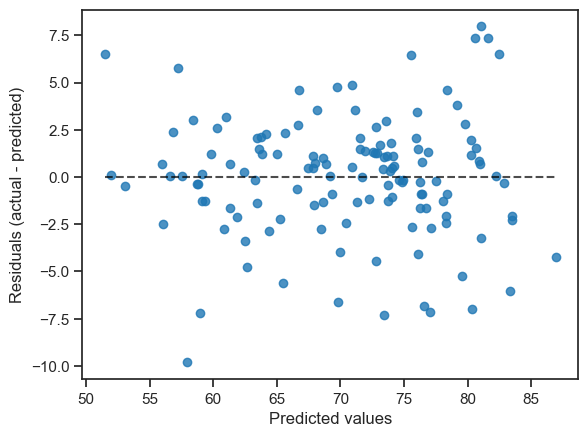

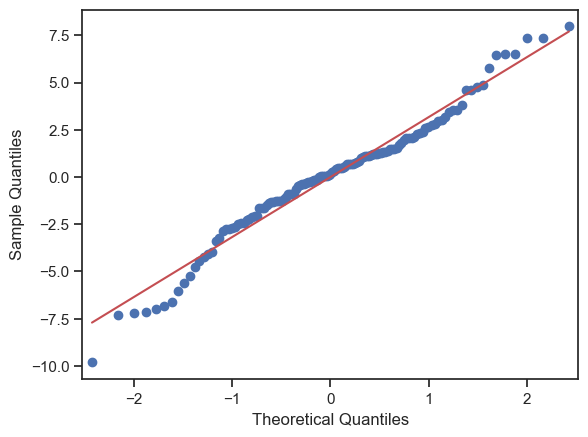

In [47]:
from sklearn.metrics import PredictionErrorDisplay
# the code below get the predict values for all of the values in x
y_hat = full_model_a.predict(x2)
# below makes a 
display = PredictionErrorDisplay(y_true=y, y_pred=y_hat)
display.plot()
plt.show()

# calculate the residuals 
residuals = y -y_hat
# generate the qq plot and put a line through the points to help us visualize the relationship here    
sm.qqplot(residuals, line ='s') 
# 
py.show() 

I'm feeling kind lucky with this.  Both of those residual plots look pretty good.  That gives me confidence that as we take out predictors we will still have a viable model.

For me next steps will be to do some model building/feature selection.  We're going to use all subsets regression and cross validation.  We have *13* predictors in the full model.  I could probably do all 13^2-1 models. but that is many, many, many models.




Below is code that was generated by gemini to give me the best 'm' models with 1, 2, 3, ..., k predictors.

In [48]:
def get_best_subsets(df, target_col, k, m):
    """
    df: Pandas DataFrame
    target_col: String name of the dependent variable
    k: Max number of predictors in a model
    m: Number of top models to return for each size
    """
    X_all = df.drop(columns=[target_col])
    y = df[target_col]
    n = len(y)
    results = []

    # Iterate through model sizes from 1 to k
    for size in range(1, k + 1):
        subset_list = []
        
        # Generate all possible combinations of predictors for this size
        for combo in combinations(X_all.columns, size):
            X_subset = X_all[list(combo)]
            
            # Fit Model
            model = LinearRegression()
            model.fit(X_subset, y)
            
            # Statistics
            y_pred = model.predict(X_subset)
            r2 = r2_score(y, y_pred)
            
            # Adjusted R-Squared
            # Formula: 1 - [(1-R2)*(n-1) / (n-p-1)]
            p = size
            adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
            
            # AIC and BIC (Assuming Gaussian Likelihood)
            # RSS = Sum of Squared Residuals
            rss = np.sum((y - y_pred) ** 2)
            
            # Using standard log-likelihood approximations
            # AIC = n * ln(RSS/n) + 2p
            # BIC = n * ln(RSS/n) + p * ln(n)
            # Note: We add 1 to p to account for the intercept
            p_total = p + 1 
            aic = n * np.log(rss / n) + 2 * p_total
            bic = n * np.log(rss / n) + p_total * np.log(n)
            
            subset_list.append({
                'model_size': size,
                'predictors': combo,
                'r_squared': r2,
                'adj_r_squared': adj_r2,
                'aic': aic,
                'bic': bic
            })
        
        # Sort by Adjusted R-Squared (descending) and take top m
        top_m = sorted(subset_list, key=lambda x: x['adj_r_squared'], reverse=True)[:m]
        results.extend(top_m)

    return pd.DataFrame(results)

# --- Example Usage ---
# df = pd.read_csv("your_data.csv")
# top_models = get_best_subsets(df, 'target_column_name', k=3, m=2)
# print(top_models)

In [49]:
top_models = get_best_subsets(df_le, 'life_expectancy', k=8, m=5)
print(top_models)

KeyboardInterrupt: 

Text(0.5, 1.0, 'BIC vs model size')

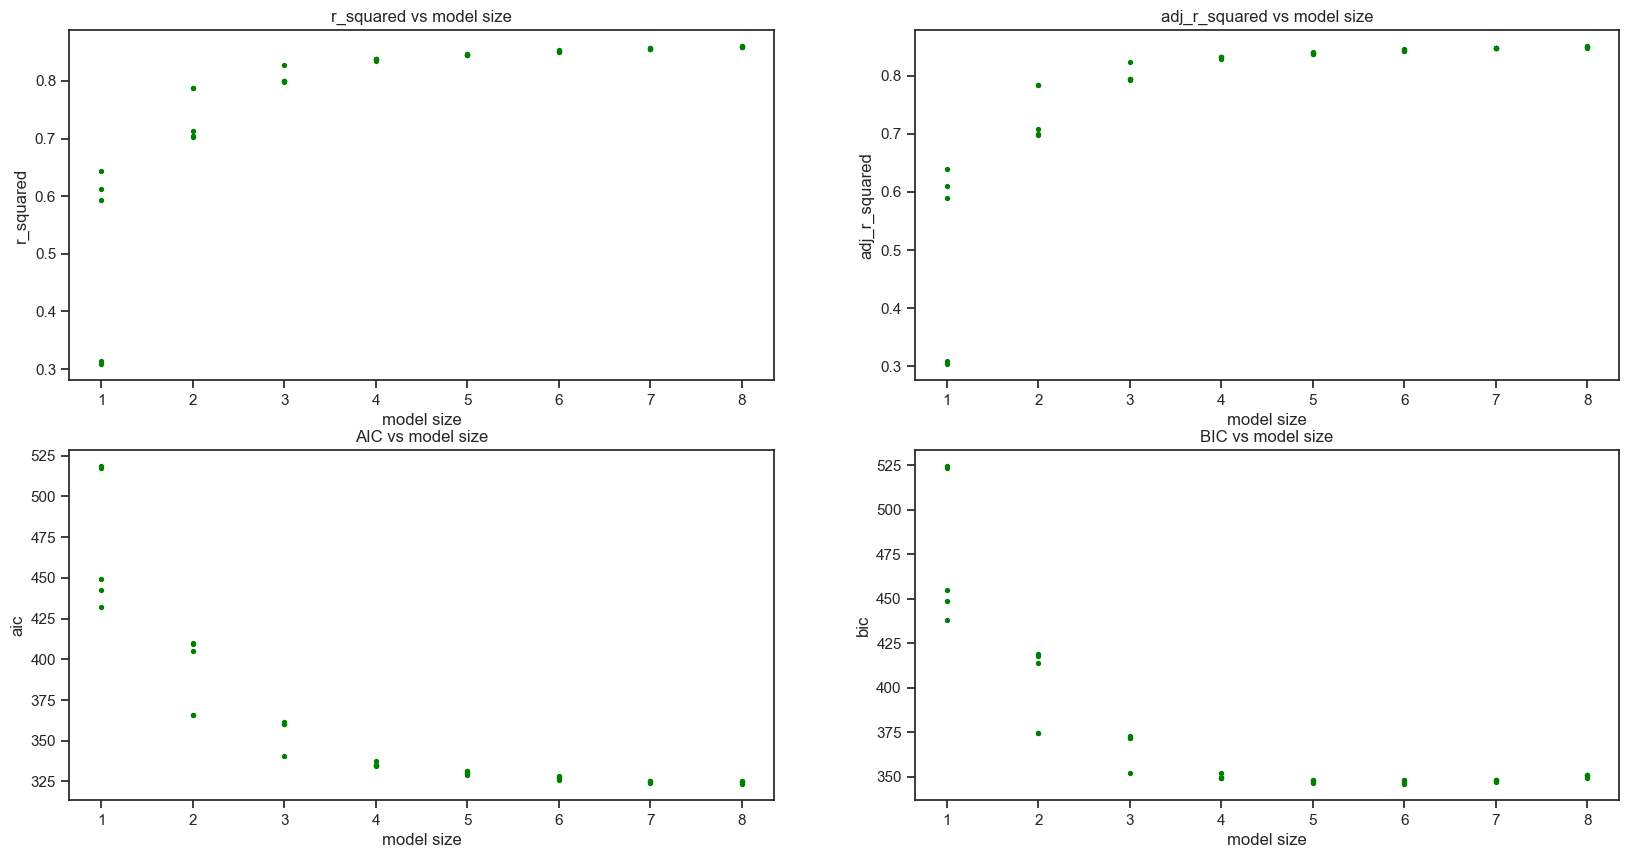

In [ ]:
plt.figure(figsize=(20,10))
plt.rcParams.update({'font.size': 18, 'lines.markersize': 10})


plt.subplot(2, 2, 1)
plt.scatter( top_models['model_size'],top_models['r_squared'], color="green", s=8)

# Add labels and title
plt.xlabel('model size')
plt.ylabel('r_squared')
plt.title('r_squared vs model size')

plt.subplot(2, 2, 2)
plt.scatter( top_models['model_size'],top_models['adj_r_squared'], color="green",s=8)

# Add labels and title
plt.xlabel('model size')
plt.ylabel('adj_r_squared')
plt.title('adj_r_squared vs model size')

# Set up a 2x2 grid so we can look at 4 plots at once
plt.subplot(2, 2, 3)
plt.scatter( top_models['model_size'],top_models['aic'], color="green", s=8)

# Add labels and title
plt.xlabel('model size')
plt.ylabel('aic')
plt.title('AIC vs model size')

plt.subplot(2, 2, 4)
plt.scatter( top_models['model_size'],top_models['bic'], color="green",s=8)

# Add labels and title
plt.xlabel('model size')
plt.ylabel('bic')
plt.title('BIC vs model size')

I'm going to focus on the best models with 3, 4 or 5 predictors here.  

I'd like to look at these models but I've not found a good way to present the output in python so here is a crude version.

In [ ]:
for row in top_models.itertuples(index=False):
    print(row.model_size," ",row.predictors,"    ",row.aic, "    ", row.bic)


1   ('schooling',)      432.0294521405028      437.7798467869051
1   ('log_hiv_aids',)      442.70738739202653      448.45778203842883
1   ('adult_mortality',)      449.15363861749296      454.90403326389526
1   ('log_infant_deaths',)      517.5637943059405      523.3141889523429
1   ('bmi_z',)      518.6344907967941      524.3848854431965
2   ('schooling', 'log_hiv_aids')      365.9567332163924      374.5823251859959
2   ('adult_mortality', 'schooling')      365.9611574287873      374.5867493983908
2   ('log_gdp', 'log_hiv_aids')      405.31170656544714      413.9372985350506
2   ('adult_mortality', 'log_hiv_aids')      409.17951079045554      417.805102760059
2   ('adult_mortality', 'alcohol')      410.0537803859451      418.6793723555486
3   ('adult_mortality', 'schooling', 'log_hiv_aids')      340.3348330301821      351.8356223229867
3   ('adult_mortality', 'alcohol', 'schooling')      360.29330104403346      371.79409033683805
3   ('schooling', 'log_infant_deaths', 'log_hiv_aids')

From the above we are going to focus on the models with 'adult_mortality', 'schooling', 'log_hiv_aids', 'log_gdp' and 'developed'.  (Perhaps we could consider 'alcohol')

Here are the model's I'd like to focus on and see which does best for cross validation

3   ('adult_mortality', 'schooling', 'log_hiv_aids')      340.3348330301821      351.8356223229867
4   ('adult_mortality', 'alcohol', 'schooling', 'log_hiv_aids')      334.5754633010339      348.95144991703967
4   ('adult_mortality', 'total_expenditure', 'schooling', 'log_hiv_aids')      334.821355227255      349.1973418432608
4   ('adult_mortality', 'schooling', 'log_gdp', 'log_hiv_aids')      334.9535226328194      349.32950924882516
4   ('adult_mortality', 'schooling', 'log_hiv_aids', 'developed')      335.1378623759485      349.51384899195426
4   ('adult_mortality', 'schooling', 'log_infant_deaths', 'log_hiv_aids')      337.73753163234323      352.113518248349
5   ('adult_mortality', 'schooling', 'log_gdp', 'log_hiv_aids', 'developed')      329.12502902587863      346.37621296508553
5   ('adult_mortality', 'total_expenditure', 'schooling', 'log_gdp', 'log_hiv_aids')      329.82932306657017      347.08050700577706
5   ('adult_mortality', 'alcohol', 'total_expenditure', 'schooling', 'log_hiv_aids')      330.35986811250564      347.61105205171253
5   ('adult_mortality', 'alcohol', 'schooling', 'log_gdp', 'log_hiv_aids')      331.11366679941034      348.36485073861724
5   ('adult_mortality', 'total_expenditure', 'schooling', 'log_hiv_aids', 'developed')      331.13112456758023      348.3823085067871

In [ ]:
top_models_subset=top_models.iloc[[10, 15, 16,17,18,19,20,21,22,23,24]]
print(top_models_subset)

    model_size                                         predictors  r_squared  \
10           3         (adult_mortality, schooling, log_hiv_aids)   0.827984   
15           4  (adult_mortality, alcohol, schooling, log_hiv_...   0.837877   
16           4  (adult_mortality, total_expenditure, schooling...   0.837573   
17           4  (adult_mortality, schooling, log_gdp, log_hiv_...   0.837409   
18           4  (adult_mortality, schooling, log_hiv_aids, dev...   0.837180   
19           4  (adult_mortality, schooling, log_infant_deaths...   0.833916   
20           5  (adult_mortality, schooling, log_gdp, log_hiv_...   0.846840   
21           5  (adult_mortality, total_expenditure, schooling...   0.846015   
22           5  (adult_mortality, alcohol, total_expenditure, ...   0.845390   
23           5  (adult_mortality, alcohol, schooling, log_gdp,...   0.844498   
24           5  (adult_mortality, total_expenditure, schooling...   0.844477   

    adj_r_squared         aic         b

### Cross Validation

We're going to do some cross validation to decide between these models.

Here is some slick code courtesy of Gemini that will allows us to loop through the possible models and get the mean cross validated RMSE for each of the models in 'top_models_subset'.  

Aren't computers amazing!!

But when I run this I get a really weird error despite getting the output.

In [51]:
top_models_subset['cv_avg_rmse']=0.00

for index, row in top_models_subset.iterrows():
    # Extract the tuple of predictors and convert to a list
    current_predictors = list(row['predictors'])
  
    le_model = sklearn_sm(sm.OLS)
    # 3. Subset the original data using these predictors
    X = df_le[current_predictors]
    y = df_le['life_expectancy']
    
    # 4. Fit the model
    cv = KFold(n_splits=6,
           shuffle=True,
           random_state=20260319)
    results = cross_validate(le_model,
                         X,
                         y,
                         cv=cv,
                         scoring=('neg_mean_squared_error'));
    print(np.sqrt(-1*results['test_score']).mean())
    #top_models_subset.at[row,'cv_avg_rmse']=np.sqrt(-1*results['test_score']).mean()
    # note that I tried to assign the 
    
   

C:\Users\mschuck1\AppData\Local\Temp\1\ipykernel_13908\617942158.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_models_subset['cv_avg_rmse']=0.00


8.813221308316914
8.633041457465149
8.762172139449703
8.398571610342165
8.613008655168967
8.316262985145395
8.225571321920945
8.412995079535502
8.482880040104515
8.191743683214591
8.541241262418673


Over several different random seeds I got that the 2nd to the last model gives the best.  This is the model with 5 predictors and those predictors are: 'adult_mortality', 'alcohol', 'schooling', 'log_gdp', 'log_hiv_aids']

In [ ]:

X = df_le[['adult_mortality', 'alcohol', 'schooling', 'log_gdp', 'log_hiv_aids']]
y = df_le['life_expectancy']

# Create a linear regression model
final_model = LinearRegression()

# Fit the model on the  data
final_model.fit(X, y)

# Make predictions on the  data
y_hat = final_model.predict(X)

# Evaluate the model
rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)

x2 = sm.add_constant(X)

#fit linear regression model
final_model_a = sm.OLS(y, x2).fit()

#view model summary
print(final_model_a.summary())

Root Mean Squared Error: 3.3803900243395466
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     135.8
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           9.09e-49
Time:                        13:25:38   Log-Likelihood:                -345.44
No. Observations:                 131   AIC:                             702.9
Df Residuals:                     125   BIC:                             720.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

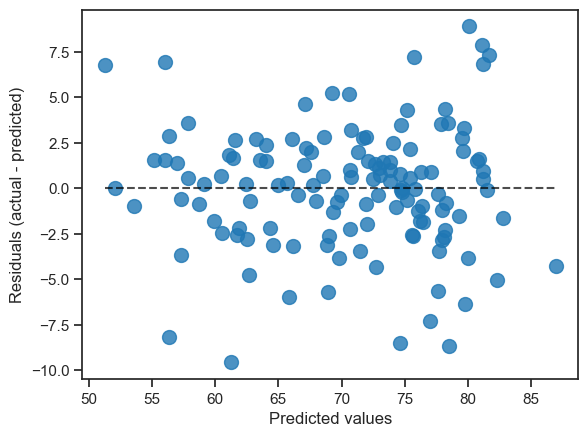

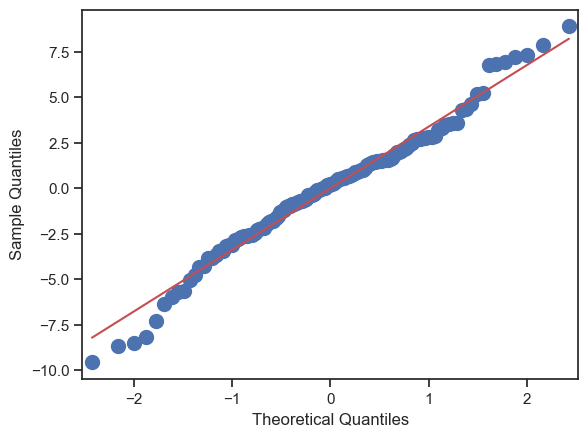

In [ ]:
#y_hat = final_model_a.predict(x2)
# below makes a 
display = PredictionErrorDisplay(y_true=y, y_pred=y_hat)
display.plot()
plt.show()

# calculate the residuals 
residuals = y -y_hat
# generate the qq plot and put a line through the points to help us visualize the relationship here    
sm.qqplot(residuals, line ='s') 
# 
py.show() 

Whew!  Things still look good from a residuals standpoint.  

Some final notes:

+ I don't love adult_mortality as a predictor though it can be a proxy for violent crimes in a country.  It seems like it is too much a response-like feature rather than an input.

+ For our models because of the lack of multicollinearity and the utility of our predictors, the r-squared values are close to the adj_r_squarted values

+ I was lucky that the residual plots looked good.  If they did not, I would have had a good deal more work to do.  Two possibilities there: transformation of response or dealing with outliers.

+ There were no outliers here so we did not need to investigate or deal with those issues.  I'm only in favor of not including a value (outlier) if we can confirm that is was collected under a different process than other data points.  

+ Our RMSE for the final model all data was $3.4$ years, while the best we did out of sample was just under $8$ years.  Big difference.

+ We would still have to interpret the terms of our model.

+ Theoretical considerations: if we had wanted to evaluate a particular predictor we can build models so that predictors is in all of the models that we consider.

+ Along the way I made several choices.  That is something that happens as you do a model buiding process.

